# **Clustering** (Sesi 19-20, 11 May 2026)

Fadhlan Nur Rachman (2802491960)

Dataset : https://www.kaggle.com/datasets/youssefaboelwafa/clustering-penguins-species/data

Data Dictionary :
- culmen_length_mm: paruh length (mm)
- culmen_depth_mm: paruh depth (mm)
- flipper_length_mm: sayap length (mm)
- body_mass_g: body mass (g)
- sex: penguin jenis kelamin



In [1]:
# import dataset
import pandas as pd

df =pd.read_csv('datapenguin/penguins.csv')
print(df.shape)
df.head()

(344, 5)


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,NaN,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0,FEMALE


**Interpretasi cell diatas**:

terdapat data penguin yang akan di clustering (tanpa label) sebanyak 344 baris dan 5 fitur. dan terlihat juga pada data baris ke 3 terdapat satu baris NaN yang benar benar tidak ada isinya dan ini harus dihapus


# Exploratory Data Analysis dan Data Preprocessing

In [2]:
# Check structure of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   342 non-null    float64
 1   culmen_depth_mm    342 non-null    float64
 2   flipper_length_mm  342 non-null    float64
 3   body_mass_g        342 non-null    float64
 4   sex                335 non-null    object 
dtypes: float64(4), object(1)
memory usage: 13.6+ KB


**Interpretasi cell diatas**:

menampilkan informasi dari setiap fitur beserta data yang ada di setiap fitur (non-null) secara lengkap dengan tipe datanya. informasi yang di dapatkan adalah banyak data keseluruhan 344 baris namun di setiap fitur paling tinggi hanya ada 342 yang terisi, lalu fitur sex hanya terdapat 335 baris yang terindikasi bahwa ada 9 data yang tidak ada valuenya pada fitur sex

In [3]:
# Calculate summary statistics
df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,214.014620,4201.754386
std,5.459584,1.974793,260.558057,801.954536
min,32.100000,13.100000,-132.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.750000,4750.000000
max,59.600000,21.500000,5000.000000,6300.000000


**Interpretasi cell diatas**:

menampilkan summary statistik keempat fitur numerik penguin, rata-rata panjang paruh (culmen_length_mm) sekitar 43.92 mm dan rata-rata berat badan sekitar 4201 gram. yang perlu diperhatikan adalah nilai minimum panjang sayap yang negatif (-132) dan maksimum yang sangat tinggi (5000), ini jelas data tidak wajar yang harus dibersihkan sebelum clustering

In [4]:
# Checking for missing values
df.isnull().sum()

culmen_length_mm     2
culmen_depth_mm      2
flipper_length_mm    2
body_mass_g          2
sex                  9
dtype: int64

**Interpretasi cell diatas**:

ditemukan missing value di beberapa fitur. seluruh fitur masing masing kehilangan 2 baris, sedangkan fitur sex yang paling banyak dengan 9 baris kosong

In [5]:
# Drop Missing Values
df.dropna(inplace=True)
df.isnull().sum()

culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

**Interpretasi cell diatas**:

setelah proses dropna, semua fitur sudah tidak ada yang kosong dan missing value berhasil dihapus seluruhnya

In [6]:
# Check Duplicate Values
print(f"Number of Observations: {len(df)}")
print(f"Number of Duplicates: {df.duplicated().sum()}")

Number of Observations: 335
Number of Duplicates: 0


**Interpretasi cell diatas**:

data yang tersisa setelah drop missing value ada 335 baris dan tidak ditemukan satupun duplikat, kualitas data cukup bersih

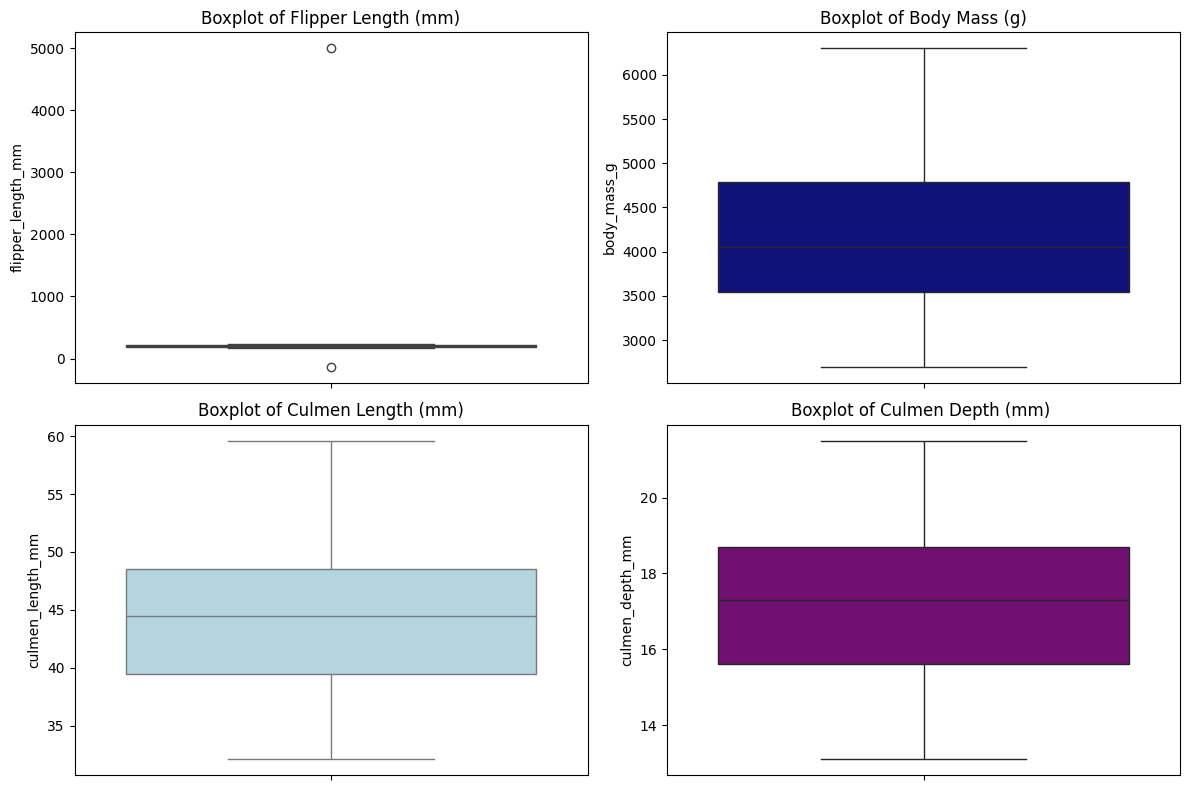

In [7]:
# Check for Outliers

import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(data=df, y='flipper_length_mm', ax=axes[0, 0])
axes[0, 0].set_title('Boxplot of Flipper Length (mm)')

sns.boxplot(data=df, y='body_mass_g', ax=axes[0, 1], color='darkblue') # dark blue
axes[0, 1].set_title('Boxplot of Body Mass (g)')

sns.boxplot(data=df, y='culmen_length_mm', ax=axes[1, 0], color='lightblue') # light blue
axes[1, 0].set_title('Boxplot of Culmen Length (mm)')

sns.boxplot(data=df, y='culmen_depth_mm', ax=axes[1, 1], color='purple') # purple
axes[1, 1].set_title('Boxplot of Culmen Depth (mm) ')  

plt.tight_layout()
plt.show()


**Interpretasi cell diatas**:

menampilkan boxplot untuk menunjukan adanya outlier yang sangat ekstrem terutama pada fitur panjang sayap dengan titik yang jauh di luar whisper. outlier ini perlu ditangani agar tidak mengganggu hasil clustering nantinya

In [8]:
# Check Minus Value in Flipper Length

print((df['flipper_length_mm'] < 0).value_counts())
df[df['flipper_length_mm'] < 0]

flipper_length_mm
False    334
True       1
Name: count, dtype: int64


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
14,34.6,21.1,-132.0,4400.0,MALE


**Interpretasi cell diatas**:

ditemukan 1 baris dengan nilai negatif pada panjang sayap yaitu -132 di baris ke-14. nilai ini jelas tidak masuk akal karena panjang sayap penguin tidak mungkin negatif sehingga harus dihapus

In [9]:
# Handling the Errorneous Data

df = df[df['flipper_length_mm'] != -132]

# Reset index after dropping the erroneous data
df.reset_index(drop=True, inplace=True)

print(df[df['flipper_length_mm'] == -132])

Empty DataFrame
Columns: [culmen_length_mm, culmen_depth_mm, flipper_length_mm, body_mass_g, sex]
Index: []


**Interpretasi cell diatas**:

menampilkan data anomali panjang sayap = -132 sudah berhasil dihapus, terlihat dari output yang mengembalikan dataframe kosong

In [10]:
# Check Value > 4000 in Flipper Length

print((df['flipper_length_mm'] > 4000).value_counts())
print(df[df['flipper_length_mm'] > 4000])

flipper_length_mm
False    333
True       1
Name: count, dtype: int64
   culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g   sex
7              42.0             20.2             5000.0       4250.0  MALE


**Interpretasi cell diatas**:

masih ditemukan 1 outlier ekstrem lagi yaitu panjang sayap = 5000 di baris ke-7. nilai ini tidak realistis karena berarti sayap penguin sepanjang 5 meter sehingga ikut dihapus

In [11]:
# Drop Outlier

df = df[df['flipper_length_mm'] <= 4000]
df.reset_index(drop=True, inplace=True)
df.head(10)

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,36.7,19.3,193.0,3450.0,FEMALE
4,39.3,20.6,190.0,3650.0,MALE
5,38.9,17.8,181.0,3625.0,FEMALE
6,39.2,19.6,195.0,4675.0,MALE
7,41.1,17.6,182.0,3200.0,FEMALE
8,38.6,21.2,191.0,3800.0,MALE
9,36.6,17.8,185.0,3700.0,FEMALE


**Interpretasi cell diatas**:

menampilkan outlier panjang sayap ekstrem dengan nilai 5000 sudah dihapus. data yang tersisa 332 baris dan 10 data pertama sudah menunjukan nilai yang wajar dan normal

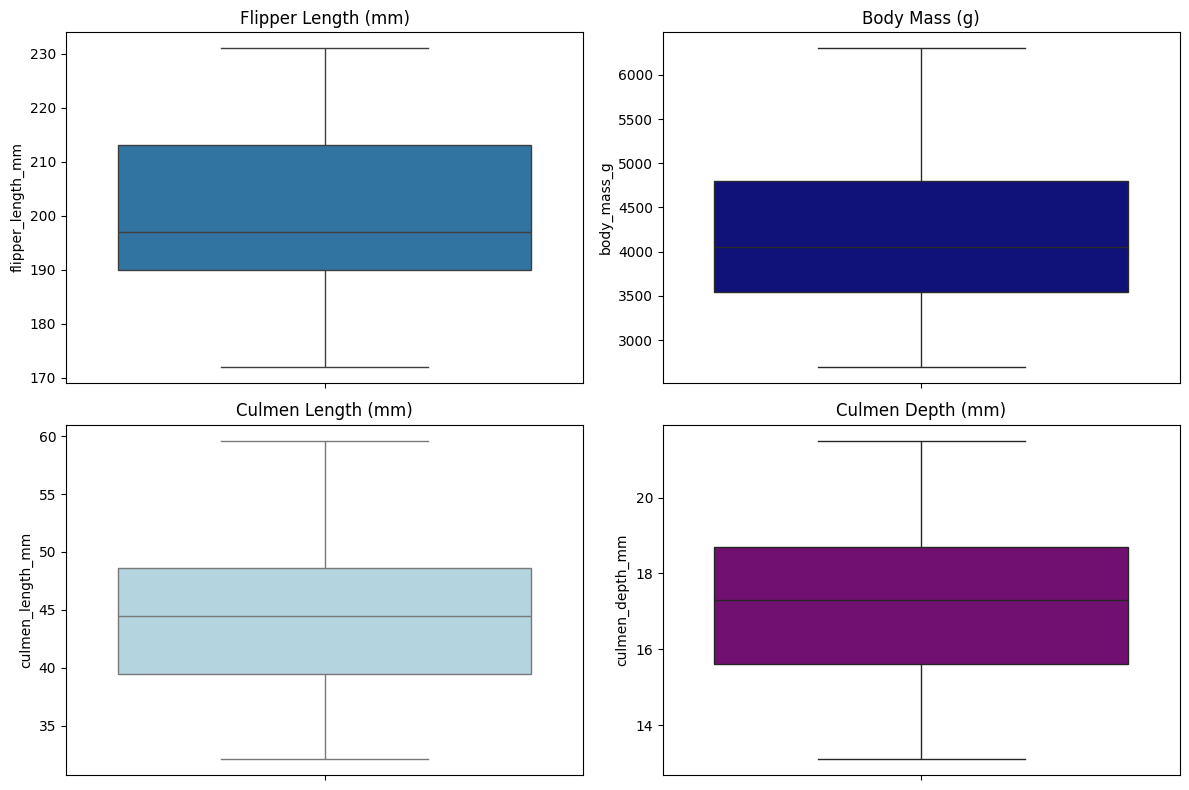

In [12]:
# Check for Outliers using Boxplots

import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(data=df, y='flipper_length_mm', ax=axes[0, 0])
axes[0, 0].set_title('Flipper Length (mm)')

sns.boxplot(data=df, y='body_mass_g', ax=axes[0, 1], color='darkblue') # dark blue
axes[0, 1].set_title('Body Mass (g)')

sns.boxplot(data=df, y='culmen_length_mm', ax=axes[1, 0], color='lightblue') # light blue
axes[1, 0].set_title('Culmen Length (mm)')

sns.boxplot(data=df, y='culmen_depth_mm', ax=axes[1, 1], color='purple') # purple
axes[1, 1].set_title('Culmen Depth (mm)')

plt.tight_layout()
plt.show()

**Interpretasi cell diatas**:

menampilkan boxplot setelah pembersihan outlier menunjukan distribusi keempat fitur yang jauh lebih wajar tanpa nilai ekstrem. data sudah bersih dan siap masuk ke tahap clustering

In [13]:
# Check Distribution of Sex

df['sex'].value_counts()

sex
MALE      167
FEMALE    165
.           1
Name: count, dtype: int64

**Interpretasi cell diatas**:

distribusi jenis kelamin hampir seimbang dengan 167 MALE dan 165 FEMALE, namun ada 1 data dengan nilai '.' yang merupakan input yang salah dan perlu diperbaiki

In [14]:
# Handling Error in Sex

print(df[df['sex']=='.'])
df['sex'] = df['sex'].replace('.', 'MALE')

     culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g sex
326              44.5             15.7              217.0       4875.0   .


**Interpretasi cell diatas**:

ditemukan 1 baris di index 326 dengan nilai sex = '.' yang tidak valid, sehingga diganti dengan 'MALE' mengikuti nilai yang paling sering muncul

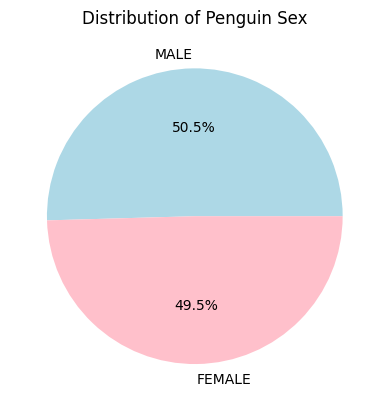

In [15]:
# Visualize Distribution of Sex

plt.pie(df['sex'].value_counts(), labels=df['sex'].value_counts().index, autopct='%1.1f%%', colors=['lightblue', 'pink']) # light blue for male, pink for female

plt.title('Distribution of Penguin Sex')
plt.show()

**Interpretasi cell diatas**:

menampilkan pie chart menunjukan distribusi jenis kelamin penguin yang cukup seimbang antara MALE dan FEMALE, sehingga fitur sex tidak akan mendominasi proses clustering secara berlebihan

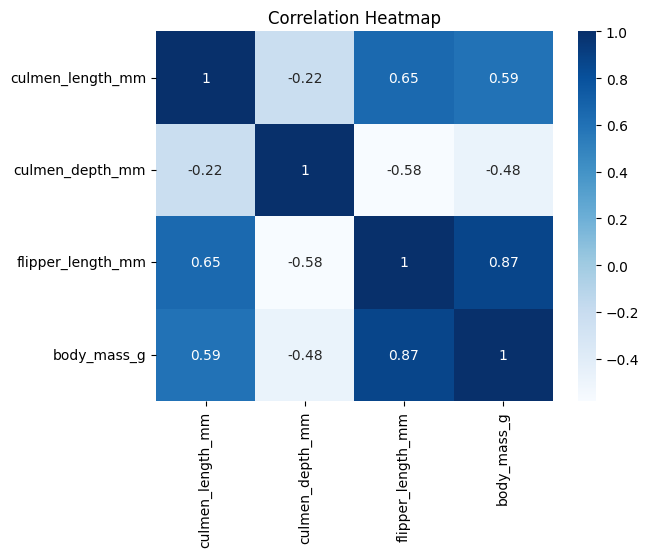

In [16]:
# Check Correlation

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()

**Interpretasi cell diatas**:

menampilkan heatmap korelasi antar fitur yang menunjukan flipper_length_mm dan body_mass_g memiliki korelasi positif tinggi, artinya penguin berbadan besar cenderung bersayap lebih panjang. culmen_depth_mm berkorelasi negatif dengan culmen_length_mm yang akan menjadi pembeda penting antar spesies penguin

In [17]:
# Encoding

df['sex'] = df['sex'].map({'MALE': 1, 'FEMALE': 0})

**Interpretasi cell diatas**:

fitur sex diubah dari teks menjadi numerical supaya bisa diolah oleh algoritma clustering yang hanya memproses data numerik

In [18]:
# Min-max Scaling

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

df_scaled = scaler.fit_transform(df)
df_scaled

array([[0.25454545, 0.66666667, 0.15254237, 0.29166667, 1.        ],
       [0.26909091, 0.51190476, 0.23728814, 0.30555556, 0.        ],
       [0.29818182, 0.58333333, 0.38983051, 0.15277778, 0.        ],
       ...,
       [0.66545455, 0.30952381, 0.84745763, 0.84722222, 1.        ],
       [0.47636364, 0.20238095, 0.6779661 , 0.69444444, 0.        ],
       [0.64727273, 0.35714286, 0.69491525, 0.75      , 1.        ]],
      shape=(333, 5))

**Interpretasi cell diatas**:

seluruh fitur di-scaling menggunakan MinMaxScaler agar berada di rentang 0 hingga 1. dan sangat penting bagi K-Means karena supaya rata ketika nanti menghitung jarak euclidean nya

# K-Means Model

## Elbow Method

In [19]:
# Elbow method
from sklearn.cluster import KMeans

inertia = []
for i in range(1, 16):
    model = KMeans(n_clusters=i, max_iter=300, random_state=42)
    model.fit(df)
    inertia.append(model.inertia_)

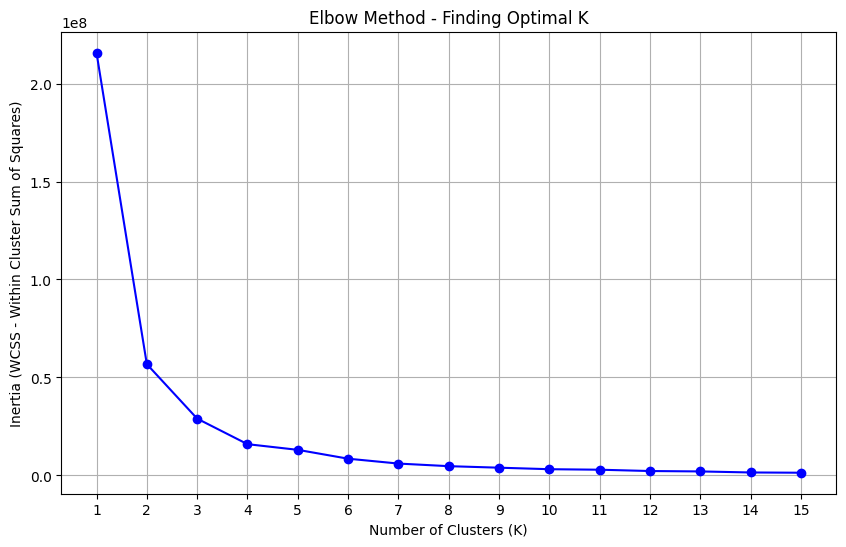

In [20]:
# Visualize Elbow Method

plt.figure(figsize=(10, 6))
plt.plot(range(1, 16), inertia, marker='o', color='blue')
plt.xticks([j for j in range(1, 16)])
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS - Within Cluster Sum of Squares)')
plt.title('Elbow Method - Finding Optimal K')
plt.grid(True)
plt.show()

**Interpretasi cell diatas**:

menampilkan grafik elbow method menunjukan penurunan inertia (WCSS) yang signifikan dari K=1 hingga K=4. setelah K=4 kurva mulai mendatar membentuk 'siku', yang berarti K=4 adalah jumlah cluster optimal karena penambahan cluster setelah itu tidak memberikan penurunan inertia yang berarti

## Silhouette Method

In [21]:
# Silhouette Method - hitung skor untuk setiap nilai K
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, max_iter=300, random_state=42)
    labels = km.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    silhouette_scores.append(score)

# Tampilkan skor setiap K
for k, score in zip(k_range, silhouette_scores):
    print(f"K={k:2d} | Silhouette Score: {score:.4f}")

optimal_k_sil = list(k_range)[silhouette_scores.index(max(silhouette_scores))]
print(f"\nOptimal K (Silhouette Method): {optimal_k_sil}")

K= 2 | Silhouette Score: 0.5607
K= 3 | Silhouette Score: 0.5580
K= 4 | Silhouette Score: 0.6145
K= 5 | Silhouette Score: 0.5753
K= 6 | Silhouette Score: 0.5276
K= 7 | Silhouette Score: 0.4853
K= 8 | Silhouette Score: 0.4104
K= 9 | Silhouette Score: 0.3683
K=10 | Silhouette Score: 0.3614

Optimal K (Silhouette Method): 4


**Interpretasi cell diatas**:

silhouette score dihitung untuk setiap nilai K dari 2 sampai 10 menggunakan data yang sudah di-scaling. semakin tinggi nilainya (mendekati 1) berarti cluster semakin kompak dan terpisah. dari hasil ini bisa dilihat K berapa yang menghasilkan skor tertinggi yang akan dikonfirmasi lewat grafik

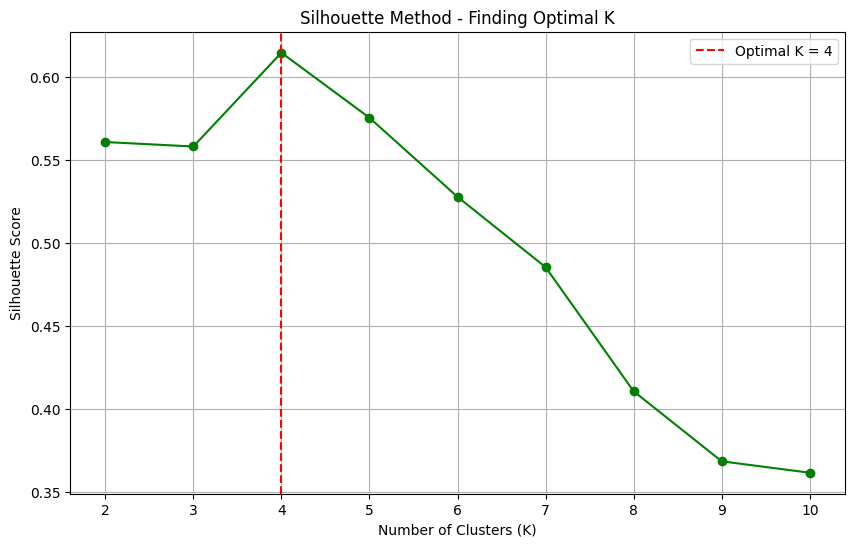

In [22]:
# Visualisasi Silhouette Method
plt.figure(figsize=(10, 6))
plt.plot(list(k_range), silhouette_scores, marker='o', color='green')
plt.xticks(list(k_range))
plt.axvline(x=optimal_k_sil, color='red', linestyle='--', label=f'Optimal K = {optimal_k_sil}')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method - Finding Optimal K')
plt.legend()
plt.grid(True)
plt.show()

**Interpretasi cell diatas**:

menampilkan grafik silhouette method menampilkan puncak tertinggi yang ditandai garis merah putus-putus sebagai K optimal. ini mengkonfirmasi hasil elbow method bahwa K=4 adalah jumlah cluster paling optimal untuk dataset penguin ini. semakin tinggi silhouette score semakin jelas pemisahan antar cluster yang terbentuk

## Model Development

In [23]:
# make cluster
model = KMeans(n_clusters=4, max_iter=300, random_state=42)
model.fit(df_scaled)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


**Interpretasi cell diatas**:

memanggil model dari libray dan model K-Means dibangun dengan 4 cluster sesuai kesimpulan dari elbow dan silhouette method. max_iter=300 memastikan model punya cukup iterasi untuk menemukan centroid yang stabil, dan random_state=42 dipakai supaya hasilnya konsisten setiap kali dijalankan

In [24]:
# predict the cluster for each data point

cluster_labels = model.predict(df_scaled)

df['cluster'] = cluster_labels

df_scaled_k_means = pd.DataFrame(df_scaled).copy()
df_scaled_k_means['cluster'] = cluster_labels

# Check the Results
print(df_scaled_k_means['cluster'].value_counts())

cluster
2    107
0    106
3     62
1     58
Name: count, dtype: int64


**Interpretasi cell diatas**:

333 data penguin berhasil dikelompokkan ke 4 cluster: 
- cluster 2 paling banyak ada 107 data
- cluster 0 ada 106 data, 
- cluster 3 ada 62 data,
- cluster 1 paling sedikit ada 58 data.

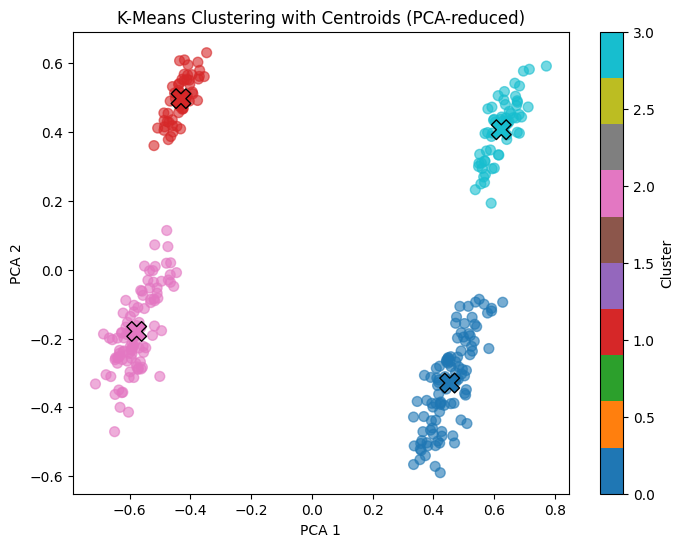

In [25]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced_data = pca.fit_transform(df_scaled_k_means.drop('cluster', axis=1))
centers = pca.transform(model.cluster_centers_)

# Plot data points
plt.figure(figsize=(8, 6))
plt.scatter(reduced_data[:, 0], reduced_data[:, 1],
            c=df['cluster'], cmap='tab10', s=50, alpha=0.6)

# Plot centroids
plt.scatter(centers[:, 0], centers[:, 1],
            c=range(model.n_clusters), cmap='tab10', 
            marker='X', s=200, edgecolor='black')

plt.title('K-Means Clustering with Centroids (PCA-reduced)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(label='Cluster')
plt.show()

**Interpretasi cell diatas**:

menampilkan PCA mereduksi 5 dimensi fitur menjadi 2 komponen utama agar bisa divisualisasikan. tanda X menampilkan posisi centroid setiap cluster. keempat cluster terlihat lumayan terpisah, menunjukan hasil clustering K-Means cukup baik

# K-Means Evaluation

In [26]:
from sklearn.metrics import silhouette_score

evaluation = silhouette_score(df_scaled_k_means, model.labels_)
print("Silhouette Score:", evaluation)

Silhouette Score: 0.7937750369818518


**Interpretasi cell diatas**:

silhouette score K-Means sebesar 0.7938 termasuk kategori sangat baik karena mendekati nilai maksimal 1. artinya setiap data penguin sudah berada di cluster yang paling tepat dan jauh dari cluster lainnya. skor di atas 0.7 umumnya dianggap hasil clustering yang sangat memuaskan

In [27]:
# Interpretasi isi dari setiap clusternya

df_analysis = df.copy()
df_analysis['cluster'] = df['cluster']

# Rata-Rata tiap cluster
print("Karakteristik Setiap Cluster\n")
print(df_analysis.groupby('cluster').mean(numeric_only=True).round(2))

Karakteristik Setiap Cluster

         culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g  \
cluster                                                                      
0                   43.88            19.11             194.76      4006.60   
1                   45.56            14.24             212.71      4679.74   
2                   40.22            17.61             189.05      3419.16   
3                   49.39            15.72             221.47      5475.00   

         sex  
cluster       
0        1.0  
1        0.0  
2        0.0  
3        1.0  


**Interpretasi cell diatas**:

tabel rata-rata fitur per cluster memperlihatkan profil masing-masing kelompok penguin:
- Cluster 0: penguin jantan dengan paruh sedang dan berat menengah sekitar 4006g
- Cluster 1: penguin betina cukup besar dengan paruh panjang dan sayap cukup panjang yaitu 212mm
- Cluster 2: penguin betina paling kecil memiliki sayap 189mm, berat 3419g
- Cluster 3: penguin jantan dengan badan besar-besar memiliki rata2 sayap 221mm dan berat 5475g

# Hierarchical Clustering

## Dendrogram

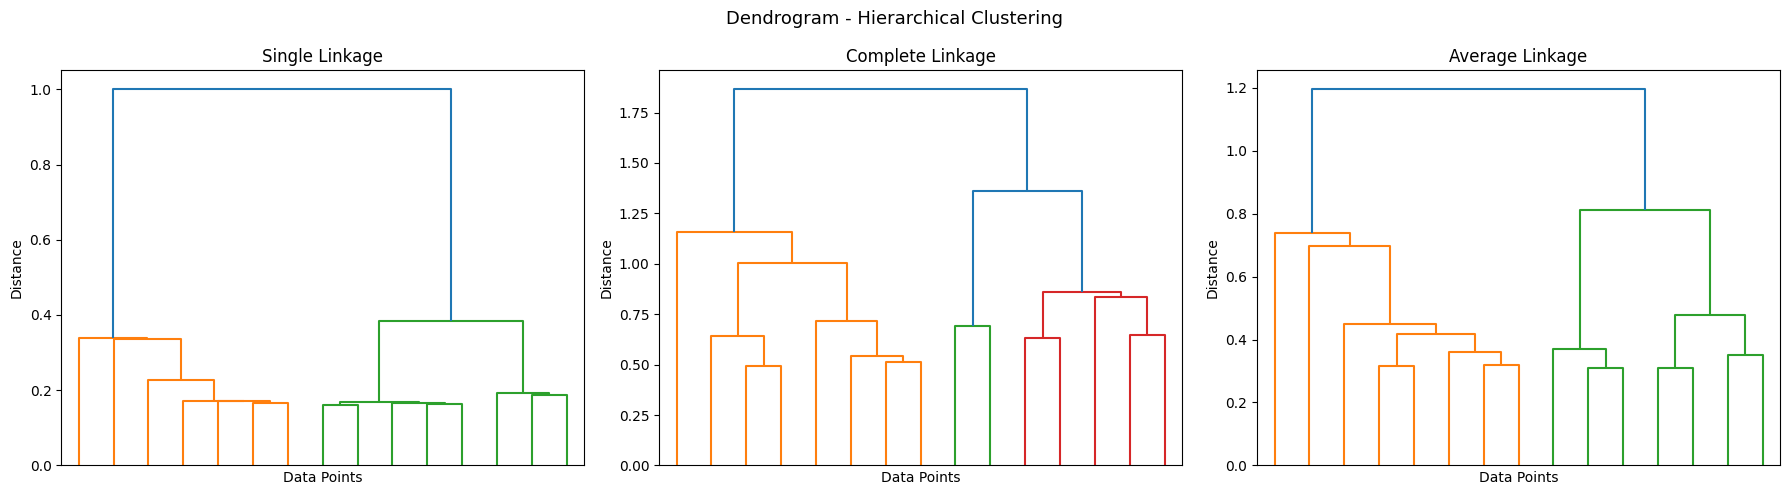

In [28]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

linkage_methods = ['single', 'complete', 'average']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, method in zip(axes, linkage_methods):
    linked = linkage(df_scaled, method=method)
    dendrogram(linked, ax=ax, truncate_mode='lastp', p=15, no_labels=True)
    ax.set_title(f'{method.capitalize()} Linkage')
    ax.set_xlabel('Data Points')
    ax.set_ylabel('Distance')

plt.suptitle('Dendrogram - Hierarchical Clustering', fontsize=13)
plt.tight_layout()
plt.show()

**Interpretasi cell diatas**:

dendrogram menggambarkan proses penggabungan data secara hierarkis dari bawah ke atas. garis horizontal yang lebih tinggi artinya penggabungan dua kelompok yang makin berbeda. single linkage cenderung membentuk rantai panjang, complete linkage lebih kompak, sedangkan average linkage berada di tengah keduanya

## Silhouette Score - Menentukan K Optimal

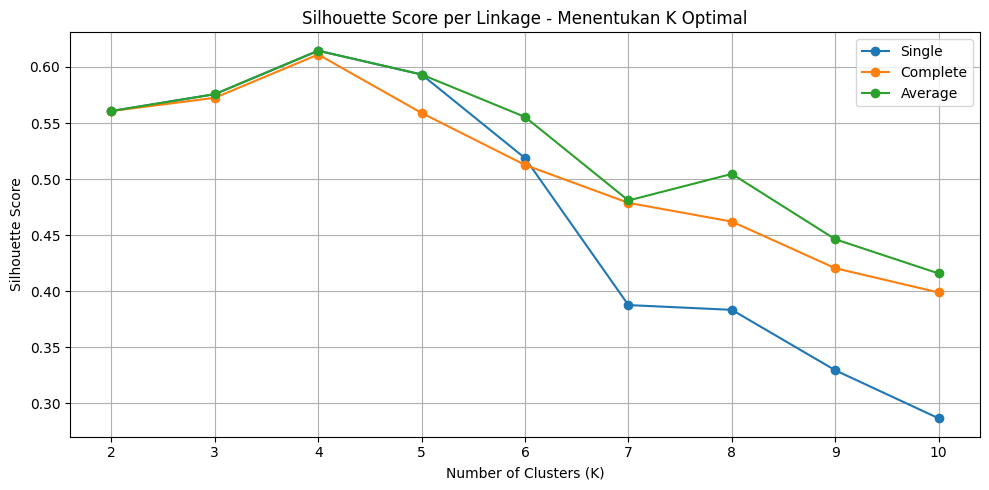

Linkage       Optimal K   Silhouette Score
Single                4             0.6145
Complete              4             0.6111
Average               4             0.6145


In [29]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

k_range = range(2, 11)
hc_sil_scores = {}

for method in linkage_methods:
    scores = []
    for k in k_range:
        labels = AgglomerativeClustering(n_clusters=k, linkage=method).fit_predict(df_scaled)
        scores.append(silhouette_score(df_scaled, labels))
    hc_sil_scores[method] = scores

plt.figure(figsize=(10, 5))
for method, scores in hc_sil_scores.items():
    plt.plot(list(k_range), scores, marker='o', label=method.capitalize())
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score per Linkage - Menentukan K Optimal')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

optimal_k_hc = {}
print(f'{"Linkage":<12} {"Optimal K":>10} {"Silhouette Score":>18}')
for method, scores in hc_sil_scores.items():
    best_k = list(k_range)[scores.index(max(scores))]
    optimal_k_hc[method] = best_k
    print(f'{method.capitalize():<12} {best_k:>10} {max(scores):>18.4f}')

**Interpretasi cell diatas**:

silhouette score dihitung untuk setiap nilai K (2 sampai 10) pada ketiga linkage method. nilai K dengan skor tertinggi pada masing-masing linkage dipilih sebagai K optimal. perbedaan optimal K antar linkage menunjukan bahwa cara penggabungan cluster mempengaruhi struktur data yang terbentuk

## Model Development

In [30]:
hc_labels_all = {}

for method in linkage_methods:
    k = optimal_k_hc[method]
    labels = AgglomerativeClustering(n_clusters=k, linkage=method).fit_predict(df_scaled)
    hc_labels_all[method] = labels
    dist = pd.Series(labels).value_counts().sort_index().to_dict()
    print(f'{method.capitalize()} Linkage | K={k} | Distribusi: {dist}')

Single Linkage | K=4 | Distribusi: {0: 107, 1: 62, 2: 106, 3: 58}
Complete Linkage | K=4 | Distribusi: {0: 107, 1: 107, 2: 61, 3: 58}
Average Linkage | K=4 | Distribusi: {0: 107, 1: 106, 2: 62, 3: 58}


**Interpretasi cell diatas**:

ketiga model agglomerative clustering dibangun dengan K optimal yang berbeda-beda sesuai hasil silhouette score. distribusi cluster menunjukan berapa data yang masuk ke setiap kelompok pada masing-masing linkage method

## Visualisasi Hasil Clustering

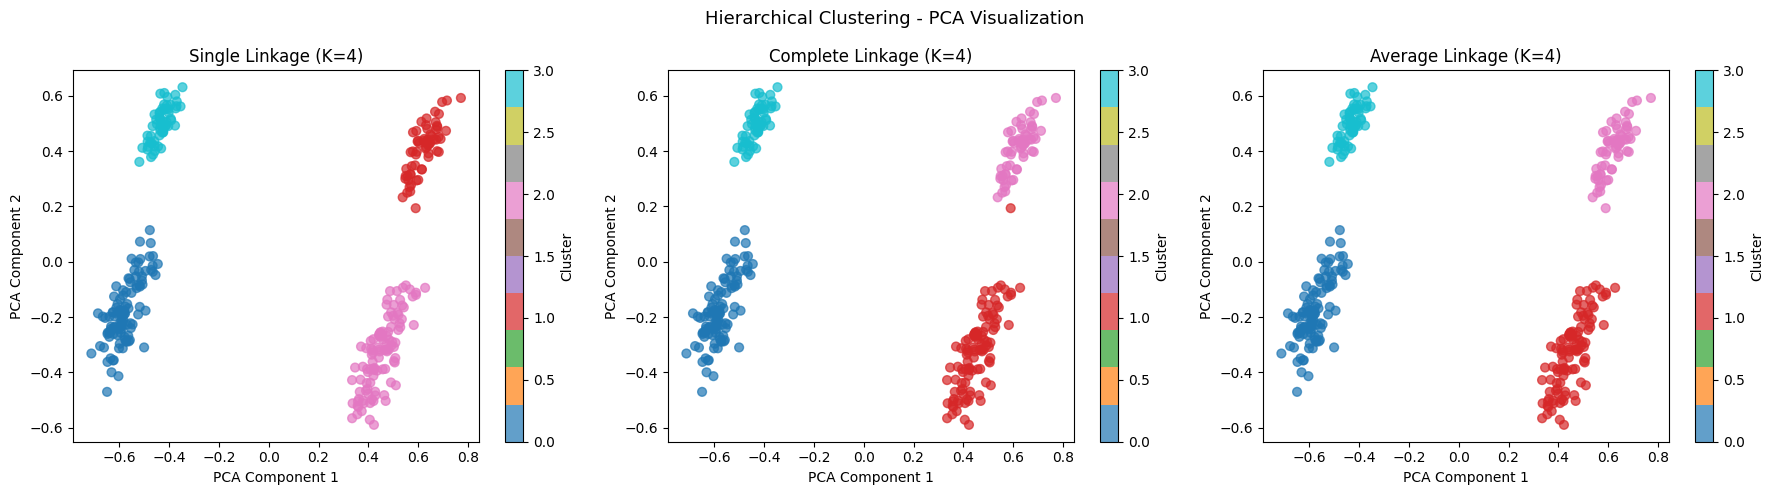

In [31]:
from sklearn.decomposition import PCA

pca_hc = PCA(n_components=2)
reduced_hc = pca_hc.fit_transform(df_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, method in zip(axes, linkage_methods):
    labels = hc_labels_all[method]
    scatter = ax.scatter(reduced_hc[:, 0], reduced_hc[:, 1],
                         c=labels, cmap='tab10', s=40, alpha=0.7)
    ax.set_title(f'{method.capitalize()} Linkage (K={optimal_k_hc[method]})')
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')
    plt.colorbar(scatter, ax=ax, label='Cluster')

plt.suptitle('Hierarchical Clustering - PCA Visualization', fontsize=13)
plt.tight_layout()
plt.show()

**Interpretasi cell diatas**:

visualisasi PCA mereduksi 5 dimensi fitur menjadi 2 komponen agar bisa digambarkan. setiap warna mewakili satu cluster. perbedaan bentuk dan jumlah cluster antar linkage method terlihat jelas di sini, dimana single linkage cenderung menghasilkan cluster yang tidak seimbang sedangkan complete dan average lebih merata

## Evaluasi

In [32]:
hc_eval_scores = {}

print(f'{"Linkage":<12} {"K":>4} {"Silhouette Score":>18}')
for method in linkage_methods:
    score = silhouette_score(df_scaled, hc_labels_all[method])
    hc_eval_scores[method] = score
    print(f'{method.capitalize():<12} {optimal_k_hc[method]:>4} {score:>18.4f}')

Linkage         K   Silhouette Score
Single          4             0.6145
Complete        4             0.6111
Average         4             0.6145


**Interpretasi cell diatas**:

tabel evaluasi menampilkan silhouette score final untuk ketiga linkage method. semakin tinggi nilainya berarti cluster yang terbentuk semakin kompak dan terpisah dengan baik. nilai ini akan digunakan pada comparative analysis untuk membandingkan semua metode clustering

# DBSCAN
Density-Based Spatial Clustering of Applications with Noise

## Menentukan MinPts

In [33]:
# Aturan umum: MinPts = 2 x jumlah fitur
n_features = df_scaled.shape[1]
MinPts = 2 * n_features

print(f'Jumlah fitur (D) : {n_features}')
print(f'MinPts = 2 x D   : {MinPts}')
print()
print('MinPts menentukan berapa minimum tetangga yang dibutuhkan')
print('agar sebuah titik dianggap sebagai core point dalam cluster.')

Jumlah fitur (D) : 5
MinPts = 2 x D   : 10

MinPts menentukan berapa minimum tetangga yang dibutuhkan
agar sebuah titik dianggap sebagai core point dalam cluster.


**Interpretasi cell diatas**:

MinPts ditentukan menggunakan aturan umum yaitu 2 kali jumlah fitur (dimensi). dataset penguin memiliki 5 fitur sehingga MinPts = 2 x 5 = 10. semakin tinggi MinPts, semakin ketat syarat untuk menjadi core point sehingga cluster yang terbentuk lebih padat dan lebih sedikit noise yang diabaikan

## Menentukan Epsilon (K-Distance Plot)

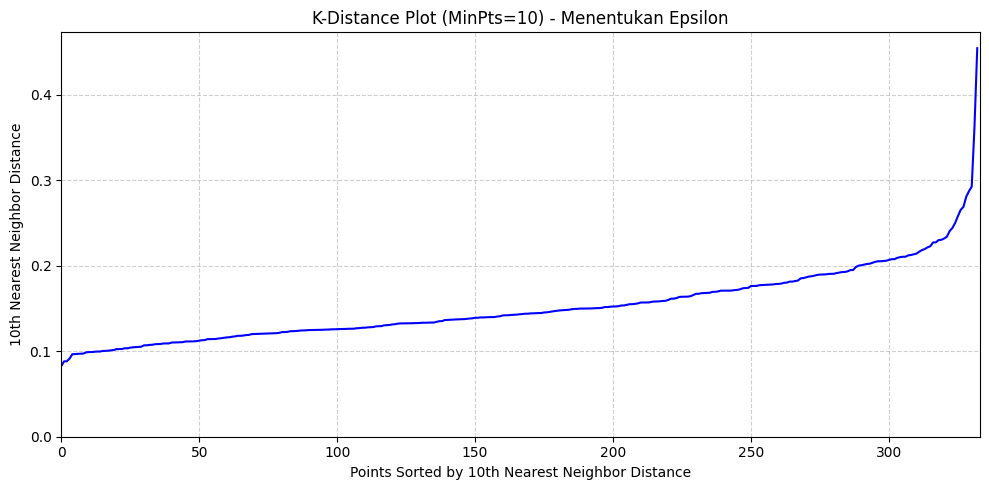

In [34]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

nbrs = NearestNeighbors(n_neighbors=MinPts).fit(df_scaled)
distances, _ = nbrs.kneighbors(df_scaled)

# Urutkan ascending - titik siku (knee) = nilai eps optimal
k_distances = np.sort(distances[:, MinPts - 1])

plt.figure(figsize=(10, 5))
plt.plot(k_distances, color='blue')
plt.xlim(0, len(k_distances))
plt.ylim(0)
plt.xlabel(f'Points Sorted by {MinPts}th Nearest Neighbor Distance')
plt.ylabel(f'{MinPts}th Nearest Neighbor Distance')
plt.title(f'K-Distance Plot (MinPts={MinPts}) - Menentukan Epsilon')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Interpretasi cell diatas**:

k-distance plot menampilkan jarak setiap titik ke tetangga ke-MinPts terdekat, diurutkan dari kecil ke besar. grafik dimulai dari titik (0,0) dan naik perlahan hingga muncul titik siku yang naik tajam. nilai epsilon yang optimal diambil dari jarak pada titik siku tersebut karena di situlah batas antara titik yang masih berdekatan dan titik yang mulai terpencar

## Model Development

In [35]:
from sklearn.cluster import DBSCAN

# Epsilon dibaca dari titik siku pada k-distance plot
eps = 0.3

dbscan = DBSCAN(eps=eps, min_samples=MinPts)
dbscan_labels = dbscan.fit_predict(df_scaled)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise       = int((dbscan_labels == -1).sum())

print(f'MinPts         : {MinPts}')
print(f'Epsilon (eps)  : {eps}')
print(f'Jumlah Cluster : {n_clusters_db}')
print(f'Jumlah Noise   : {n_noise}')
print(f'\nDistribusi Cluster:')
print(pd.Series(dbscan_labels).value_counts().sort_index())

MinPts         : 10
Epsilon (eps)  : 0.3
Jumlah Cluster : 4
Jumlah Noise   : 1

Distribusi Cluster:
-1      1
 0    106
 1    106
 2     58
 3     62
Name: count, dtype: int64


**Interpretasi cell diatas**:

DBSCAN dijalankan dengan MinPts dan eps yang sudah ditentukan sebelumnya. hasilnya menampilkan jumlah cluster yang ditemukan secara otomatis tanpa perlu ditentukan terlebih dahulu. titik dengan label -1 adalah noise, yaitu data yang tidak memiliki cukup tetangga dalam radius eps sehingga tidak masuk ke cluster manapun

## Visualisasi

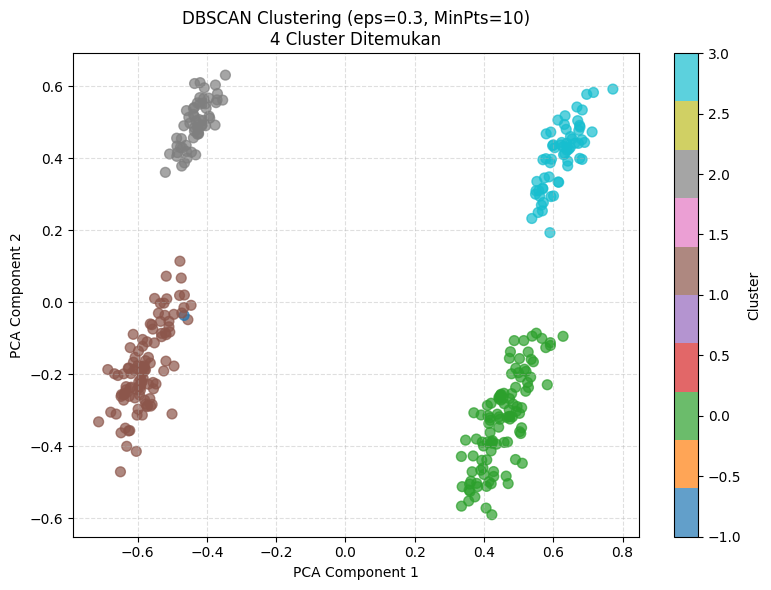

In [36]:
from sklearn.decomposition import PCA

pca_db = PCA(n_components=2)
reduced_db = pca_db.fit_transform(df_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(reduced_db[:, 0], reduced_db[:, 1],
            c=dbscan_labels, cmap='tab10', s=50, alpha=0.7)
plt.title(f'DBSCAN Clustering (eps={eps}, MinPts={MinPts})\n{n_clusters_db} Cluster Ditemukan')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Interpretasi cell diatas**:

visualisasi DBSCAN menggunakan PCA untuk mereduksi dimensi menjadi 2. setiap warna mewakili cluster yang ditemukan DBSCAN secara otomatis. DBSCAN tidak selalu menghasilkan cluster yang berbentuk bulat rapi karena algoritmanya bekerja berdasarkan kepadatan data, bukan jarak ke centroid

## Evaluasi

In [37]:
from sklearn.metrics import silhouette_score

mask = dbscan_labels != -1

if n_clusters_db >= 2 and mask.sum() > 1:
    dbscan_score = silhouette_score(df_scaled[mask], dbscan_labels[mask])
    print(f'Silhouette Score (DBSCAN, tanpa noise): {dbscan_score:.4f}')
else:
    dbscan_score = 0.0
    print(f'DBSCAN hanya menemukan {n_clusters_db} cluster.')
    print('Coba ubah nilai eps lebih kecil untuk mendapatkan lebih banyak cluster.')

Silhouette Score (DBSCAN, tanpa noise): 0.6172


**Interpretasi cell diatas**:

evaluasi DBSCAN menggunakan silhouette score hanya dari data yang masuk cluster (noise dikecualikan karena tidak punya label cluster). nilai ini menunjukan seberapa baik DBSCAN memisahkan data dibandingkan metode lainnya pada comparative analysis

# Comparative Analysis

In [38]:
from sklearn.metrics import silhouette_score

# Kumpulkan semua skor
all_scores = {
    'K-Means (K=4)'                            : evaluation,
    f'HC - Single   (K={optimal_k_hc["single"]})'  : hc_eval_scores['single'],
    f'HC - Complete (K={optimal_k_hc["complete"]})' : hc_eval_scores['complete'],
    f'HC - Average  (K={optimal_k_hc["average"]})'  : hc_eval_scores['average'],
    f'DBSCAN (eps={eps}, MinPts={MinPts})'     : dbscan_score,
}

print(f'{"Model":<35} {"Silhouette Score":>16}')
for model, score in all_scores.items():
    print(f'{model:<35} {score:>16.4f}')

best_model = max(all_scores, key=all_scores.get)
print(f'\nModel Terbaik : {best_model}')
print(f'Skor Tertinggi: {all_scores[best_model]:.4f}')

Model                               Silhouette Score
K-Means (K=4)                                 0.7938
HC - Single   (K=4)                           0.6145
HC - Complete (K=4)                           0.6111
HC - Average  (K=4)                           0.6145
DBSCAN (eps=0.3, MinPts=10)                   0.6172

Model Terbaik : K-Means (K=4)
Skor Tertinggi: 0.7938


**Interpretasi cell diatas**:

tabel comparative analysis menampilkan silhouette score seluruh model clustering. model dengan skor tertinggi adalah yang terbaik dalam memisahkan data penguin menjadi cluster yang kompak dan terpisah jelas

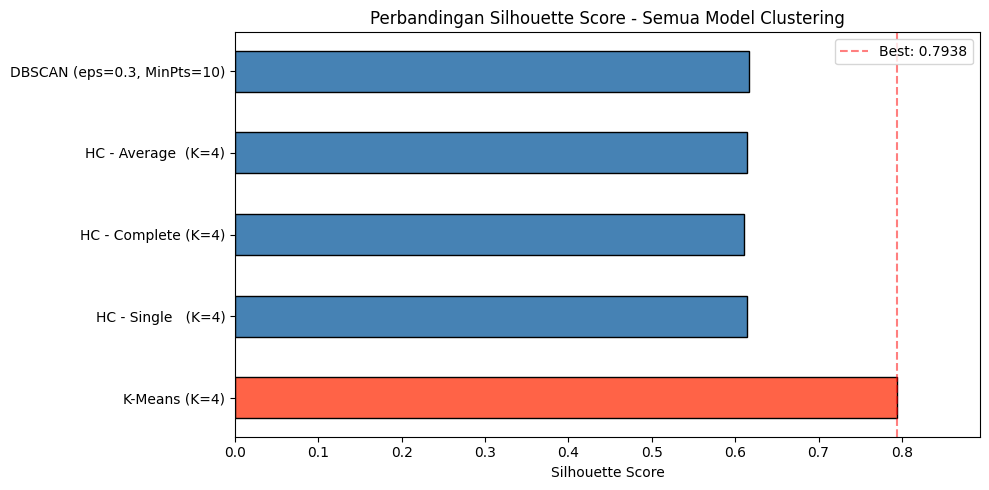

In [39]:
import numpy as np

models  = list(all_scores.keys())
scores  = list(all_scores.values())
colors  = ['steelblue' if m != best_model else 'tomato' for m in models]

plt.figure(figsize=(10, 5))
bars = plt.barh(models, scores, color=colors, edgecolor='black', height=0.5)
plt.xlabel('Silhouette Score')
plt.title('Perbandingan Silhouette Score - Semua Model Clustering')
plt.xlim(0, max(scores) + 0.1)
plt.axvline(x=max(scores), color='red', linestyle='--', alpha=0.5, label=f'Best: {max(scores):.4f}')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretasi cell diatas**:

bar chart memperlihatkan perbandingan silhouette score semua model secara visual. bar berwarna merah adalah model terbaik. skor yang lebih tinggi menandakan cluster yang lebih kompak dan terpisah lebih jelas antar satu sama lain

## Ringkasan Comparative Analysis

perbandingan ketiga metode clustering menampilkan kelebihan dan kekurangan masing-masing algoritma:
- K-Means: cepat dan sederhana, cocok untuk cluster berbentuk bulat dengan jumlah cluster yang sudah ditentukan di awal
- Hierarchical Clustering: tidak perlu menentukan jumlah cluster dari awal, struktur data bisa dilihat lewat dendrogram, namun lebih lambat untuk dataset besar
- DBSCAN: unggul untuk cluster berbentuk tidak beraturan dan otomatis mendeteksi outlier, tapi sangat sensitif terhadap pemilihan parameter eps dan min_samples tetangganya